In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
df=pd.read_csv("concrete_data.csv")
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=["Strength"]),df["Strength"],test_size=0.2,random_state=45)

In [5]:
X_train

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
582,170.3,155.5,0.0,185.7,0.0,1026.6,724.3,28
673,212.0,141.3,0.0,203.5,0.0,973.4,750.0,7
169,425.0,106.3,0.0,153.5,16.5,852.1,887.1,91
949,148.1,0.0,136.6,158.1,16.1,1001.8,830.1,28
10,198.6,132.4,0.0,192.0,0.0,978.4,825.5,90
...,...,...,...,...,...,...,...,...
580,290.2,193.5,0.0,185.7,0.0,998.2,704.3,7
163,313.3,262.2,0.0,175.5,8.6,1046.9,611.8,91
607,236.0,0.0,0.0,194.0,0.0,968.0,885.0,28
414,190.3,0.0,125.2,166.6,9.9,1079.0,798.9,3


In [9]:
# 1. Scale the features (Your existing code here is perfect)
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)



In [13]:
clf=LinearRegression()
clf.fit(X_train_scaled,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred=clf.predict(X_test_scaled)

In [15]:
r2_score(y_test,y_pred)

0.5858333407315433

In [16]:
lr=LinearRegression()
cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5)

print(f"CV Mean Score: {cv_scores.mean():.2%}")

CV Mean Score: 60.42%


# Using the power transformer

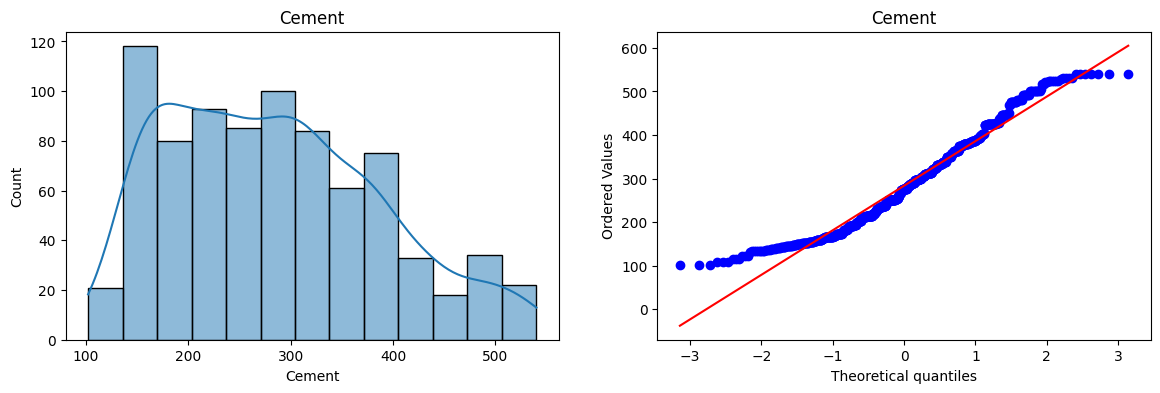

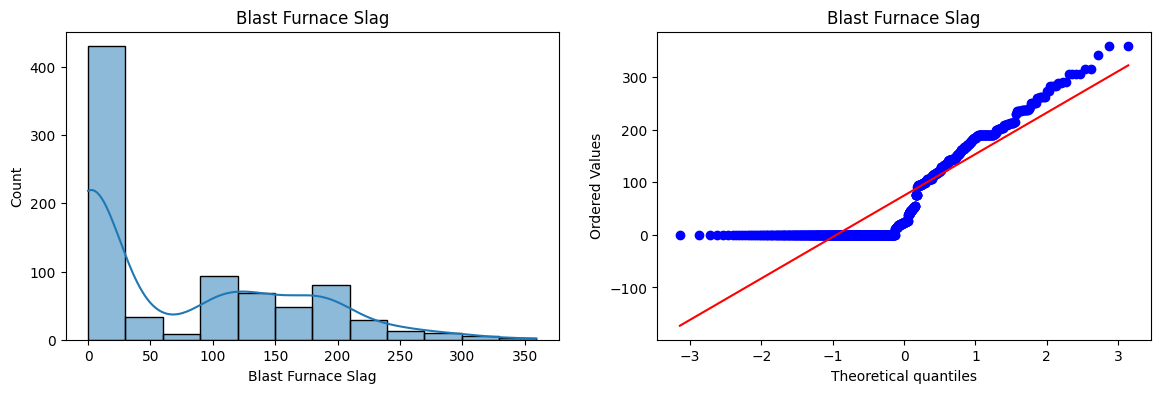

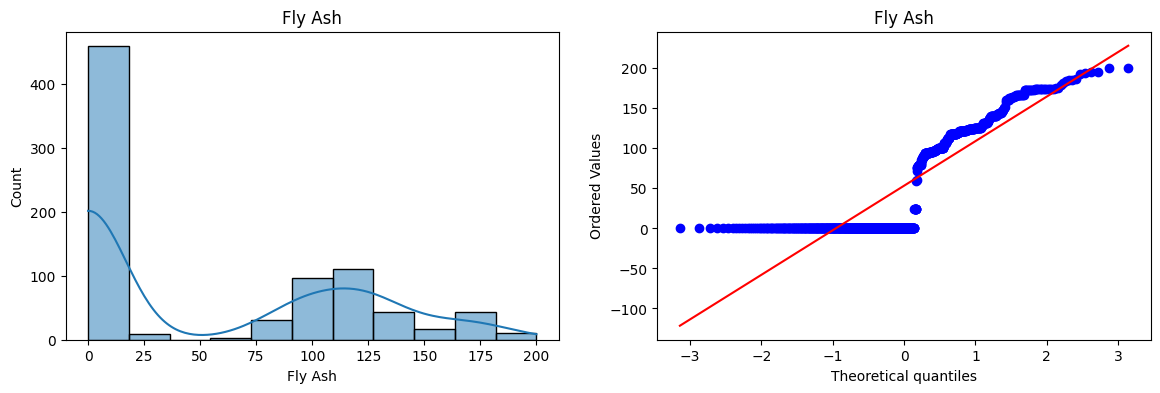

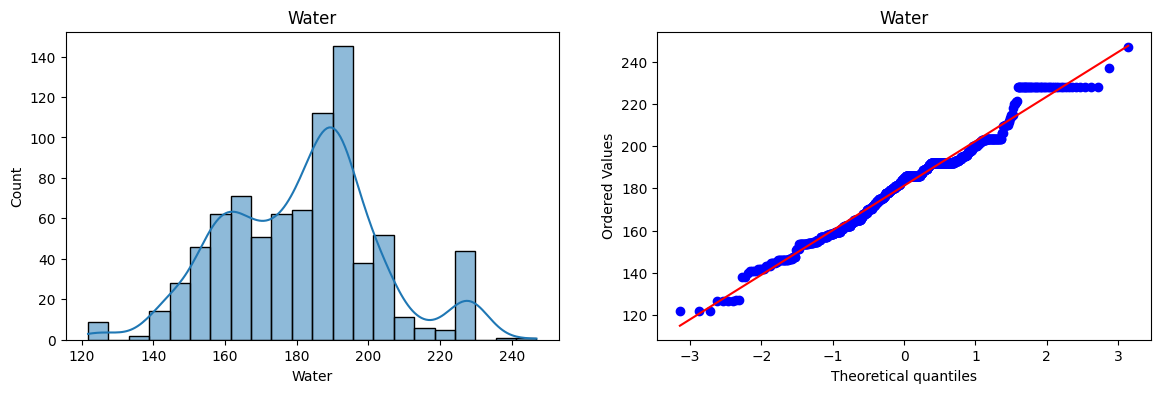

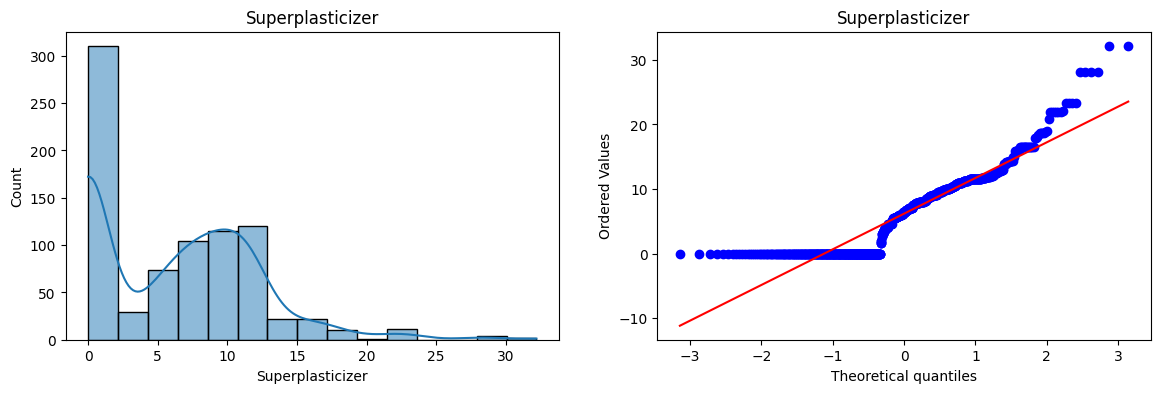

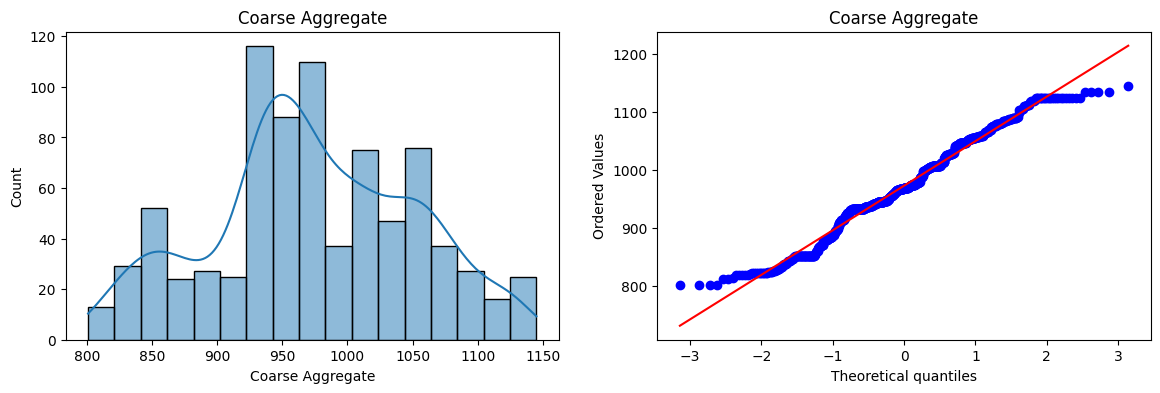

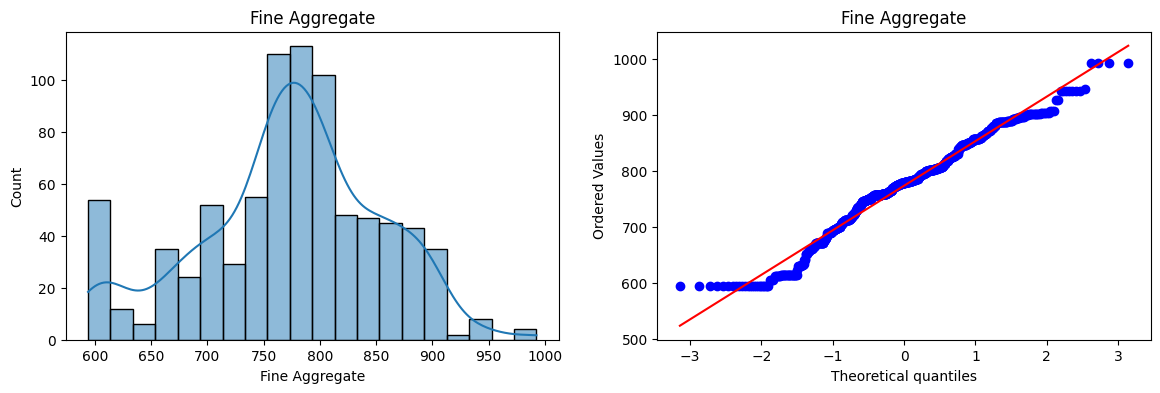

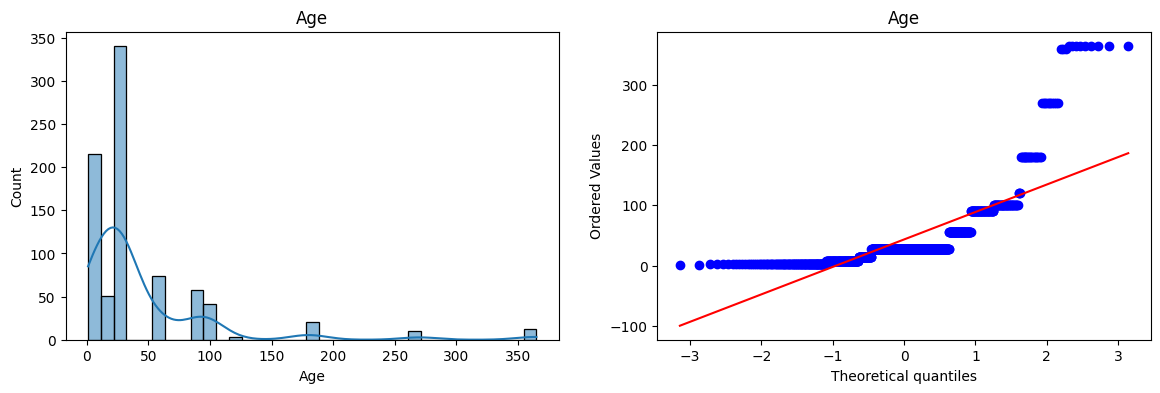

In [21]:
for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col],kde=True)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col], dist="norm", plot=plt)
    plt.title(col)

    plt.show()

In [22]:
pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.transform(X_test+0.000001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.208866
1,Blast Furnace Slag,0.030375
2,Fly Ash,-0.037325
3,Water,0.725039
4,Superplasticizer,0.097970
5,Coarse Aggregate,1.116193
6,Fine Aggregate,1.901801
7,Age,0.059211


In [23]:
lr=LinearRegression()
lr.fit(X_train_transformed,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
y_pred=lr.predict(X_test_transformed)
r2_score(y_test,y_pred)

0.7780015155156599

In [25]:
lr=LinearRegression()
cross_val=cross_val_score(lr,X_train_transformed,y_train,cv=10)
cross_val.mean()

np.float64(0.7949752558137734)